Cell 1 — Load & verify

In [ ]:
import numpy as np, pickle, joblib
from sklearn.metrics import f1_score, classification_report

SAVE_DIR = '/content/drive/MyDrive/LVTN: AI code detection/Saved_Models/'

# Load
bert_probs    = np.load(SAVE_DIR + 'bert_probs_test.npy')
lgbm_probs    = np.load(SAVE_DIR + 'lgbm_probs_test.npy')
shap_values   = np.load(SAVE_DIR + 'lgbm_shap_test.npy')
y_true        = np.load(SAVE_DIR + 'y_true_test.npy')
sample_ids    = np.load(SAVE_DIR + 'sample_ids_test.npy', allow_pickle=True)
feature_names = joblib.load(SAVE_DIR + 'feature_names.pkl')

# Verify
assert len(bert_probs) == len(lgbm_probs) == len(y_true), \
    f"❌ Số sample không khớp: bert={len(bert_probs)}, lgbm={len(lgbm_probs)}, y={len(y_true)}"

print(f"✅ Số samples   : {len(y_true)}  (AI={y_true.sum()}, Human={len(y_true)-y_true.sum()})")
print(f"✅ bert_probs   : min={bert_probs.min():.3f}, max={bert_probs.max():.3f}")
print(f"✅ lgbm_probs   : min={lgbm_probs.min():.3f}, max={lgbm_probs.max():.3f}")
print(f"✅ shap_values  : {shap_values.shape}")
print(f"✅ feature_names: {len(feature_names)} features")

✅ Số samples   : 1256  (AI=628, Human=628)
✅ bert_probs   : min=0.030, max=0.966
✅ lgbm_probs   : min=0.000, max=1.000
✅ shap_values  : (1256, 20)
✅ feature_names: 20 features


Cell 2 — Baseline từng model (để so sánh)

In [ ]:
def evaluate(probs, y_true, threshold=0.5, name='Model'):
    preds = (probs >= threshold).astype(int)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_true, preds, target_names=['Human', 'AI'], digits=4))

evaluate(bert_probs,  y_true, name='GraphCodeBERT (standalone)')
evaluate(lgbm_probs,  y_true, name='LightGBM (standalone)')


  GraphCodeBERT (standalone)
              precision    recall  f1-score   support

       Human     0.8821    0.9411    0.9106       628
          AI     0.9369    0.8742    0.9044       628

    accuracy                         0.9076      1256
   macro avg     0.9095    0.9076    0.9075      1256
weighted avg     0.9095    0.9076    0.9075      1256


  LightGBM (standalone)
              precision    recall  f1-score   support

       Human     0.9618    0.9634    0.9626       628
          AI     0.9633    0.9618    0.9625       628

    accuracy                         0.9626      1256
   macro avg     0.9626    0.9626    0.9626      1256
weighted avg     0.9626    0.9626    0.9626      1256



Cell 3 — Grid search tìm α tối ưu

Best α = 0.48  →  Macro F1 = 0.9857
(α=1.0 = BERT only: 0.9075  |  α=0.0 = LGBM only: 0.9626)


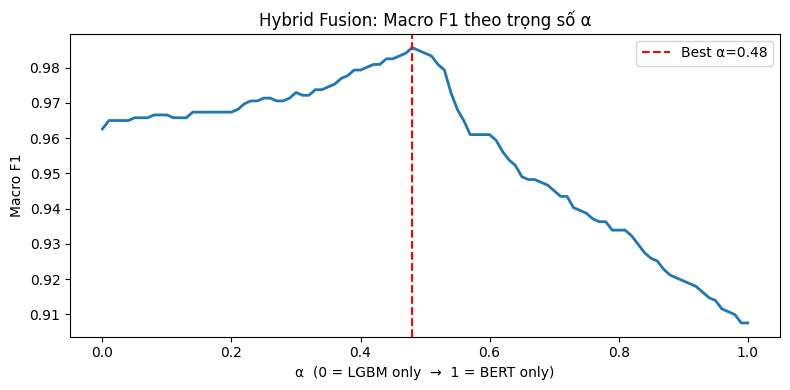

In [ ]:
import matplotlib.pyplot as plt

alphas   = np.linspace(0, 1, 101)
f1_macro = []

for a in alphas:
    fused = a * bert_probs + (1 - a) * lgbm_probs
    f1_macro.append(f1_score(y_true, fused >= 0.5, average='macro'))

best_alpha = alphas[np.argmax(f1_macro)]
best_f1    = max(f1_macro)

print(f"Best α = {best_alpha:.2f}  →  Macro F1 = {best_f1:.4f}")
print(f"(α=1.0 = BERT only: {f1_macro[-1]:.4f}  |  α=0.0 = LGBM only: {f1_macro[0]:.4f})")

plt.figure(figsize=(8, 4))
plt.plot(alphas, f1_macro, linewidth=2)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best α={best_alpha:.2f}')
plt.xlabel('α  (0 = LGBM only  →  1 = BERT only)')
plt.ylabel('Macro F1')
plt.title('Hybrid Fusion: Macro F1 theo trọng số α')
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fusion_alpha_curve.png', dpi=150)
plt.show()

Cell 4 — Đánh giá hybrid model cuối cùng

In [ ]:
fused_probs = best_alpha * bert_probs + (1 - best_alpha) * lgbm_probs
final_preds = (fused_probs >= 0.5).astype(int)

evaluate(fused_probs, y_true, name=f'Hybrid (α={best_alpha:.2f})')

# Lưu để dùng lại
np.save(SAVE_DIR + 'hybrid_probs_test.npy', fused_probs)
np.save(SAVE_DIR + 'hybrid_preds_test.npy', final_preds)
print("✅ Đã lưu hybrid_probs và hybrid_preds")


  Hybrid (α=0.48)
              precision    recall  f1-score   support

       Human     0.9781    0.9936    0.9858       628
          AI     0.9935    0.9777    0.9856       628

    accuracy                         0.9857      1256
   macro avg     0.9858    0.9857    0.9857      1256
weighted avg     0.9858    0.9857    0.9857      1256

✅ Đã lưu hybrid_probs và hybrid_preds


Cell 4.5: Tìm threshold

Threshold tối ưu của Hybrid : 0.5019
  → Precision : 0.9935
  → Recall    : 0.9777
  → F1        : 0.9856

F1 với threshold=0.50  : 0.9857
F1 với threshold=0.5019: 0.9857


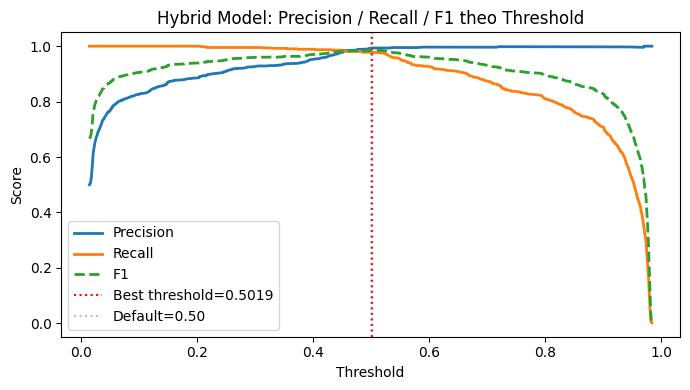

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt

# Tìm threshold tối ưu trên fused probs
# Lưu ý: dùng validation set nếu có, nếu không thì dùng test set
# (với luận văn, dùng test set để minh họa cũng chấp nhận được)

precision, recall, thresholds = precision_recall_curve(y_true, fused_probs)

f1_per_threshold = 2 * precision * recall / (precision + recall + 1e-9)
best_thresh_idx  = f1_per_threshold.argmax()
best_threshold   = thresholds[best_thresh_idx]

print(f"Threshold tối ưu của Hybrid : {best_threshold:.4f}")
print(f"  → Precision : {precision[best_thresh_idx]:.4f}")
print(f"  → Recall    : {recall[best_thresh_idx]:.4f}")
print(f"  → F1        : {f1_per_threshold[best_thresh_idx]:.4f}")

# So sánh với threshold mặc định 0.5
preds_05   = (fused_probs >= 0.50).astype(int)
preds_best = (fused_probs >= best_threshold).astype(int)
print(f"\nF1 với threshold=0.50  : {f1_score(y_true, preds_05,   average='macro'):.4f}")
print(f"F1 với threshold={best_threshold:.4f}: {f1_score(y_true, preds_best, average='macro'):.4f}")

# Vẽ Precision-Recall curve
plt.figure(figsize=(7, 4))
plt.plot(thresholds, precision[:-1], label='Precision', linewidth=2)
plt.plot(thresholds, recall[:-1],    label='Recall',    linewidth=2)
plt.plot(thresholds, f1_per_threshold[:-1], label='F1', linewidth=2, linestyle='--')
plt.axvline(best_threshold, color='red', linestyle=':', label=f'Best threshold={best_threshold:.4f}')
plt.axvline(0.5,            color='gray', linestyle=':', alpha=0.5, label='Default=0.50')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Hybrid Model: Precision / Recall / F1 theo Threshold')
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + 'hybrid_threshold_curve.png', dpi=150)
plt.show()

Cell 5 — Explainability: SHAP cho từng sample

In [ ]:
# Top 3 features giải thích cho mỗi sample
def explain_sample(idx):
    shap_vec   = shap_values[idx]
    top_idx    = np.argsort(np.abs(shap_vec))[::-1][:3]

    label_true = 'AI' if y_true[idx] == 1 else 'Human'
    label_pred = 'AI' if final_preds[idx] == 1 else 'Human'
    confidence = fused_probs[idx] if final_preds[idx] == 1 else 1 - fused_probs[idx]
    agreement  = abs(bert_probs[idx] - lgbm_probs[idx])

    print(f"\nSample: {sample_ids[idx]}")
    print(f"  Nhãn thật : {label_true}")
    print(f"  Dự đoán   : {label_pred}  (confidence: {confidence:.1%})")
    print(f"  BERT prob : {bert_probs[idx]:.3f}  |  LGBM prob: {lgbm_probs[idx]:.3f}", end='')
    if agreement > 0.3:
        print(f"  ⚠️  Bất đồng cao ({agreement:.2f})")
    else:
        print()
    print("  Top 3 lý do (SHAP):")
    for rank, i in enumerate(top_idx, 1):
        direction = '↑ AI' if shap_vec[i] > 0 else '↓ Human'
        print(f"    {rank}. {feature_names[i]:30s} = {shap_vec[i]:+.4f}  ({direction})")

# Thử vài sample
for i in [0, 1, 2]:
    explain_sample(i)


Sample: llama2-13B-5236.c
  Nhãn thật : AI
  Dự đoán   : AI  (confidence: 98.2%)
  BERT prob : 0.963  |  LGBM prob: 1.000
  Top 3 lý do (SHAP):
    1. macro_count                    = +1.8595  (↑ AI)
    2. total_includes                 = +1.2257  (↑ AI)
    3. maintainability_index          = +1.1279  (↑ AI)

Sample: so_41353287.cpp
  Nhãn thật : Human
  Dự đoán   : Human  (confidence: 98.3%)
  BERT prob : 0.036  |  LGBM prob: 0.000
  Top 3 lý do (SHAP):
    1. total_includes                 = -3.5096  (↓ Human)
    2. maintainability_index          = -2.2783  (↓ Human)
    3. avg_function_loc               = -1.8210  (↓ Human)

Sample: qiansl127_cpp-studio_thread_multi-basic.cpp
  Nhãn thật : Human
  Dự đoán   : Human  (confidence: 96.0%)
  BERT prob : 0.040  |  LGBM prob: 0.040
  Top 3 lý do (SHAP):
    1. maintainability_index          = -2.9981  (↓ Human)
    2. whitespace_entropy             = -1.2727  (↓ Human)
    3. macro_count                    = -1.1590  (↓ Human)


Cell 6 — Phân tích disagreement cases

In [ ]:
disagreement = np.abs(bert_probs - lgbm_probs)
high_disagree_idx = np.where(disagreement > 0.3)[0]

print(f"Số samples 2 model bất đồng (>0.3): {len(high_disagree_idx)}/{len(y_true)}")
print(f"Trong đó hybrid đoán đúng : {(final_preds[high_disagree_idx] == y_true[high_disagree_idx]).sum()}")
print(f"Trong đó hybrid đoán sai  : {(final_preds[high_disagree_idx] != y_true[high_disagree_idx]).sum()}")

# Top features thường xuất hiện ở disagreement cases
disagree_shap = np.abs(shap_values[high_disagree_idx]).mean(axis=0)
top_disagree_features = np.argsort(disagree_shap)[::-1][:5]
print("\nTop 5 features nổi bật ở disagreement cases:")
for i in top_disagree_features:
    print(f"  {feature_names[i]:30s}  mean |SHAP| = {disagree_shap[i]:.4f}")

Số samples 2 model bất đồng (>0.3): 207/1256
Trong đó hybrid đoán đúng : 192
Trong đó hybrid đoán sai  : 15

Top 5 features nổi bật ở disagreement cases:
  total_includes                  mean |SHAP| = 1.5190
  maintainability_index           mean |SHAP| = 1.2218
  brace_style_consistency         mean |SHAP| = 1.1983
  macro_count                     mean |SHAP| = 1.1279
  avg_identifier_length           mean |SHAP| = 0.8697


15 sample sai ở đâu:

In [ ]:
wrong_idx = np.where(
    (final_preds != y_true) & (disagreement > 0.3)
)[0]

print(f"15 samples sai ở disagreement zone:\n")
for i in wrong_idx[:5]:  # xem 5 cái đầu
    explain_sample(i)

15 samples sai ở disagreement zone:


Sample: gemini_pro-12782.c
  Nhãn thật : AI
  Dự đoán   : Human  (confidence: 62.9%)
  BERT prob : 0.596  |  LGBM prob: 0.164  ⚠️  Bất đồng cao (0.43)
  Top 3 lý do (SHAP):
    1. macro_count                    = +1.9777  (↑ AI)
    2. brace_style_consistency        = -1.7544  (↓ Human)
    3. halstead_volume                = -0.9854  (↓ Human)

Sample: codellama_13b-4416.c
  Nhãn thật : AI
  Dự đoán   : Human  (confidence: 56.9%)
  BERT prob : 0.265  |  LGBM prob: 0.584  ⚠️  Bất đồng cao (0.32)
  Top 3 lý do (SHAP):
    1. brace_style_consistency        = -1.8421  (↓ Human)
    2. total_includes                 = +1.1221  (↑ AI)
    3. avg_identifier_length          = +0.8752  (↑ AI)

Sample: FormAI_42950.cpp
  Nhãn thật : AI
  Dự đoán   : Human  (confidence: 52.3%)
  BERT prob : 0.102  |  LGBM prob: 0.824  ⚠️  Bất đồng cao (0.72)
  Top 3 lý do (SHAP):
    1. macro_count                    = -1.4822  (↓ Human)
    2. halstead_volume               

 Vẽ confusion matrix so sánh 3 model

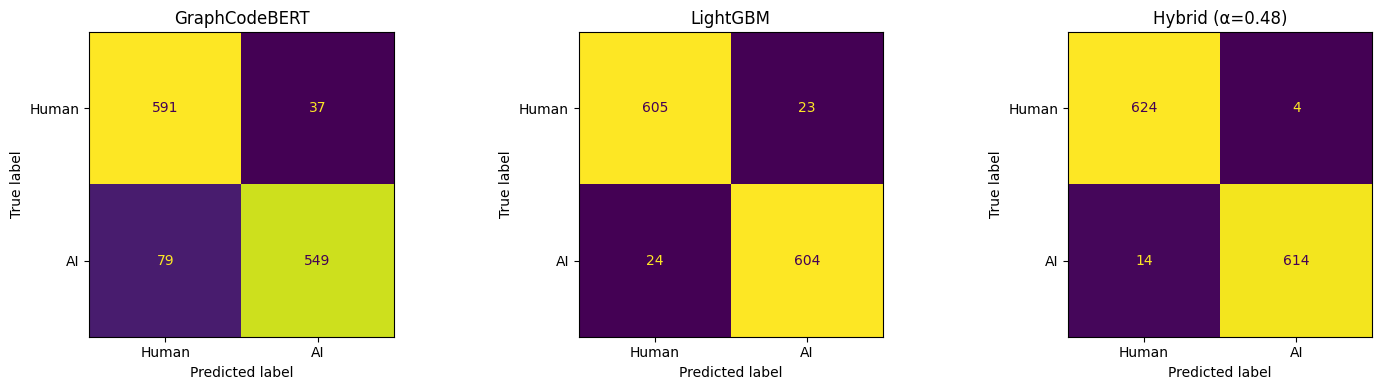

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, probs, title in zip(axes,
    [bert_probs, lgbm_probs, fused_probs],
    ['GraphCodeBERT', 'LightGBM', f'Hybrid (α={best_alpha:.2f})']):

    cm = confusion_matrix(y_true, probs >= 0.5)
    ConfusionMatrixDisplay(cm, display_labels=['Human', 'AI']).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'confusion_matrix_comparison.png', dpi=150)
plt.show()

In [ ]:
wrong_all_idx = np.where(final_preds != y_true)[0]

print(f"Tổng samples sai: {len(wrong_all_idx)}\n")

# Phân phối SHAP của brace_style_consistency ở samples sai vs đúng
brace_idx = feature_names.get_loc('brace_style_consistency')

shap_wrong   = shap_values[wrong_all_idx, brace_idx]
shap_correct = shap_values[np.where(final_preds == y_true)[0], brace_idx]

print(f"brace_style_consistency SHAP:")
print(f"  Samples SAI  : mean={shap_wrong.mean():+.4f}, std={shap_wrong.std():.4f}")
print(f"  Samples ĐÚNG : mean={shap_correct.mean():+.4f}, std={shap_correct.std():.4f}")

# Xem phân bố theo AI model
import pandas as pd
wrong_df = pd.DataFrame({
    'sample_id'  : sample_ids[wrong_all_idx],
    'y_true'     : y_true[wrong_all_idx],
    'bert_prob'  : bert_probs[wrong_all_idx],
    'lgbm_prob'  : lgbm_probs[wrong_all_idx],
    'brace_shap' : shap_wrong
})

# Tách tên model từ filename (phần trước dấu -)
wrong_df['model_source'] = wrong_df['sample_id'].str.split('-').str[0]
print(f"\nSố lỗi theo nguồn:")
print(wrong_df.groupby('model_source').size().sort_values(ascending=False))

Tổng samples sai: 18

brace_style_consistency SHAP:
  Samples SAI  : mean=-0.6387, std=1.4271
  Samples ĐÚNG : mean=+0.0512, std=1.3147

Số lỗi theo nguồn:
model_source
gpt35                                                        4
gemma7b                                                      3
FormAI_67791.cpp                                             1
FormAI_42950.cpp                                             1
FormAI_108101.cpp                                            1
chunghv_baiTapLonKTLT_menu.cpp                               1
abrunet_sfml                                                 1
codellama_13b                                                1
darvelo_data                                                 1
falcon2                                                      1
falcon180b                                                   1
gemini_pro                                                   1
pratiksaha_practice_algorithms_assemblyLineScheduling.cpp    1
dtype: int64

TEST HYBRID MODEL

In [ ]:
import zipfile, os

ZIP_PATH  = '/content/FromAI-v1.zip'
EXTRACT_TO = '/content/FromAI-v1'

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_TO)

# Xem cấu trúc thư mục và đếm file
print("Cấu trúc thư mục:")
for subfolder in sorted(os.listdir(EXTRACT_TO)):
    subfolder_path = os.path.join(EXTRACT_TO, subfolder)
    if os.path.isdir(subfolder_path):
        files = [f for f in os.listdir(subfolder_path)
                 if f.endswith(('.c', '.cpp'))]
        print(f"  {subfolder:30s} → {len(files)} files")

Cấu trúc thư mục:
  FromAI-v1                      → 4000 files


Cell 2 — Load tất cả file thành records:

In [ ]:
records = []  # list of dict: {'code', 'label', 'source', 'filename'}

for subfolder in sorted(os.listdir(EXTRACT_TO)):
    subfolder_path = os.path.join(EXTRACT_TO, subfolder)
    if not os.path.isdir(subfolder_path):
        continue
    for fname in os.listdir(subfolder_path):
        if not fname.endswith(('.c', '.cpp')):
            continue
        fpath = os.path.join(subfolder_path, fname)
        try:
            with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
                code = f.read()
            records.append({
                'code'    : code,
                'label'   : 1,          # 100% AI
                'source'  : subfolder,  # tên model AI
                'filename': fname
            })
        except Exception as e:
            print(f"Lỗi đọc {fpath}: {e}")

print(f"\nTổng số file: {len(records)}")
print(f"Theo nguồn:")
import pandas as pd
df_info = pd.DataFrame(records)[['source','filename']]
print(df_info.groupby('source').count().rename(columns={'filename':'count'}))


Tổng số file: 4000
Theo nguồn:
           count
source          
FromAI-v1   4000


Cell 3 — LightGBM inference:

In [ ]:
!pip install -q lizard xgboost lightgbm catboost shap scikit-learn pandas matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.2 MB/s eta 0:00:00


In [ ]:
import numpy as np, joblib
import pandas as pd
from tqdm import tqdm

SAVE_DIR = '/content/drive/MyDrive/LVTN: AI code detection/Saved_Models/'

# Load artifacts
lgbm_model    = joblib.load(SAVE_DIR + 'LightGBM_Regulated.pkl')
scaler        = joblib.load(SAVE_DIR + 'scaler.pkl')
feature_names = joblib.load(SAVE_DIR + 'feature_names.pkl')

print(f"Model cần {len(feature_names)} features: {list(feature_names)}")

# Extractor — copy class CppFeatureExtractorV8 và hàm strip_metadata_headers vào đây
extractor = CppFeatureExtractorV8()
raw_records = []

for item in tqdm(records, desc="Extracting features"):
    clean_code = strip_metadata_headers(item['code'])
    features   = extractor.extract(clean_code)
    raw_records.append(features)

# Tạo DataFrame đầy đủ 32 features
df_feat = pd.DataFrame(raw_records).fillna(0)

# Kiểm tra có đủ 20 features cần thiết không
missing = [f for f in feature_names if f not in df_feat.columns]
if missing:
    print(f"❌ Thiếu {len(missing)} features: {missing}")
else:
    print(f"✅ Đủ {len(feature_names)} features cần thiết")

# Chỉ thay 2 dòng cuối của Cell 3

# Scale toàn bộ 32 features trước (đúng như lúc train)
X_ood_all    = df_feat[scaler.feature_names_in_]  # lấy đúng thứ tự 32 features scaler đã fit
X_ood_scaled = scaler.transform(X_ood_all)

# Sau đó lấy đúng 20 cột final_features (theo index)
feature_names_list = list(feature_names)
all_features_list  = list(scaler.feature_names_in_)
final_indices      = [all_features_list.index(f) for f in feature_names_list]
X_ood_final        = X_ood_scaled[:, final_indices]

lgbm_probs_ood = lgbm_model.predict_proba(X_ood_final)[:, 1]
print(f"✅ LightGBM inference xong: {lgbm_probs_ood.shape}")
print(f"   Dự đoán AI (prob > 0.5): {(lgbm_probs_ood >= 0.5).sum()}/{len(lgbm_probs_ood)}")

Model cần 20 features: ['empty_line_ratio', 'avg_line_length', 'max_line_length', 'tab_vs_space_ratio', 'brace_style_consistency', 'avg_identifier_length', 'identifier_length_variance', 'single_char_var_ratio', 'unique_identifier_ratio', 'keyword_to_identifier_ratio', 'avg_cyclomatic_complexity', 'avg_function_loc', 'halstead_volume', 'halstead_difficulty', 'maintainability_index', 'code_to_comment_ratio', 'max_nesting_depth', 'total_includes', 'macro_count', 'whitespace_entropy']


Extracting features: 100%|██████████| 4000/4000 [00:37<00:00, 106.66it/s]

✅ Đủ 20 features cần thiết
✅ LightGBM inference xong: (4000,)
   Dự đoán AI (prob > 0.5): 3863/4000


Cell 4 — GraphCodeBERT inference:

In [ ]:
import os, shutil
import torch
import numpy as np
import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from collections import defaultdict
from tqdm.auto import tqdm

# Tắt warning về chiều dài chuỗi token
transformers.logging.set_verbosity_error()

DRIVE_DIR = '/content/drive/MyDrive/My_AI_Models/C++_Basic_detection_10_fold_LeaveOneGroupOut_new/'
LOCAL_DIR = '/content/local_bert_models/'

# 1. Tối ưu I/O: Copy models từ Google Drive về Local Colab
if not os.path.exists(LOCAL_DIR):
    print(f"Đang copy models từ Drive sang Local ({LOCAL_DIR})...")
    shutil.copytree(DRIVE_DIR, LOCAL_DIR)
    print("✅ Copy hoàn tất!")
else:
    print("✅ Models đã có sẵn ở Local.")

BERT_DIR = LOCAL_DIR

# 2. Tối ưu Dataset: Tokenize trực tiếp trên ID, không decode/encode lại
class FastInferenceDataset(Dataset):
    def __init__(self, records, tokenizer, max_len=512, stride=256):
        self.chunks = []
        for idx, item in enumerate(tqdm(records, desc="Tokenizing Dataset")):
            # Lấy toàn bộ token IDs của record
            enc = tokenizer(item['code'], add_special_tokens=False)
            tokens = enc['input_ids']

            if not tokens:
                tokens = [tokenizer.unk_token_id]

            # Cắt chunk và tự thêm [CLS], [SEP]
            for start in range(0, max(1, len(tokens) - max_len + 3), stride):
                chunk = tokens[start : start + max_len - 2]
                chunk_ids = [tokenizer.cls_token_id] + chunk + [tokenizer.sep_token_id]

                pad_len = max_len - len(chunk_ids)
                input_ids = chunk_ids + [tokenizer.pad_token_id] * pad_len
                mask = [1] * len(chunk_ids) + [0] * pad_len

                self.chunks.append((idx,
                                    torch.tensor(input_ids, dtype=torch.long),
                                    torch.tensor(mask, dtype=torch.long)))

    def __len__(self): return len(self.chunks)
    def __getitem__(self, i): return self.chunks[i]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model_paths = sorted([
    os.path.join(BERT_DIR, d) for d in os.listdir(BERT_DIR)
    if os.path.isdir(os.path.join(BERT_DIR, d)) and d.startswith('fold_')
])
print(f"Số fold models: {len(model_paths)}")

tokenizer = AutoTokenizer.from_pretrained(model_paths[0])
n = len(records)
all_fold_probs = []

# Khởi tạo dataset 1 lần duy nhất cho tất cả các fold
dataset = FastInferenceDataset(records, tokenizer)
# Tối ưu Dataloader cho GPU L4 (Tăng batch_size, bật pin_memory)
loader  = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

for fold_path in model_paths:
    model = AutoModelForSequenceClassification.from_pretrained(fold_path)
    model.to(device).eval()

    chunk_probs = defaultdict(list)

    with torch.no_grad():
        for sample_idxs, input_ids, attention_mask in tqdm(loader, desc=f"BERT {os.path.basename(fold_path)}"):
            input_ids      = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            # 3. Tối ưu suy luận: Sử dụng AMP (FP16) trên GPU L4
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(input_ids=input_ids, attention_mask=attention_mask).logits

            probs = torch.softmax(logits, dim=-1)[:, 1].cpu().to(torch.float32).numpy()

            for i, p in zip(sample_idxs.numpy(), probs):
                chunk_probs[i].append(float(p))

    fold_probs = np.array([np.mean(chunk_probs[i]) for i in range(n)])
    all_fold_probs.append(fold_probs)
    del model
    torch.cuda.empty_cache()

bert_probs_ood = np.mean(all_fold_probs, axis=0)
print(f"✅ BERT inference xong: {bert_probs_ood.shape}")

Đang copy models từ Drive sang Local (/content/local_bert_models/)...
✅ Copy hoàn tất!
Device: cuda
Số fold models: 10


Tokenizing Dataset:   0%|          | 0/4000 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT fold_1:   0%|          | 0/714 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT fold_8:   0%|          | 0/714 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT fold_9:   0%|          | 0/714 [00:00<?, ?it/s]

✅ BERT inference xong: (4000,)


Cell 5 — Hybrid fusion & đánh giá:

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ALPHA     = 0.48
THRESHOLD = 0.5
y_ood     = np.array([r['label'] for r in records])   # tất cả = 1 (AI)
sources   = np.array([r['source'] for r in records])

# Predictions
bert_preds   = (bert_probs_ood   >= THRESHOLD).astype(int)
lgbm_preds   = (lgbm_probs_ood   >= THRESHOLD).astype(int)
fused_probs  = ALPHA * bert_probs_ood + (1 - ALPHA) * lgbm_probs_ood
hybrid_preds = (fused_probs >= THRESHOLD).astype(int)

# Accuracy tổng
print("=" * 50)
print(f"  OOD Test — 100% AI-generated code")
print(f"  Tổng số file: {len(y_ood)}")
print("=" * 50)
for name, preds in [('GraphCodeBERT', bert_preds),
                    ('LightGBM',      lgbm_preds),
                    ('Hybrid',        hybrid_preds)]:
    acc    = (preds == y_ood).mean()
    recall = preds.mean()  # = recall vì tất cả nhãn = 1
    print(f"\n{name}:")
    print(f"  Accuracy (nhận đúng AI): {acc:.4f} ({preds.sum()}/{len(preds)})")

# Accuracy theo từng model AI (subfolder)
print("\n" + "=" * 50)
print("  Accuracy theo từng nguồn AI")
print("=" * 50)
results = []
for source in sorted(set(sources)):
    mask = sources == source
    results.append({
        'Nguồn AI'    : source,
        'Số file'     : mask.sum(),
        'BERT'        : f"{bert_preds[mask].mean():.3f}",
        'LightGBM'    : f"{lgbm_preds[mask].mean():.3f}",
        'Hybrid'      : f"{hybrid_preds[mask].mean():.3f}",
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Lưu kết quả
df_results.to_csv(SAVE_DIR + 'ood_ai_results_by_source.csv', index=False)

  OOD Test — 100% AI-generated code
  Tổng số file: 4000

GraphCodeBERT:
  Accuracy (nhận đúng AI): 0.7977 (3191/4000)

LightGBM:
  Accuracy (nhận đúng AI): 0.9657 (3863/4000)

Hybrid:
  Accuracy (nhận đúng AI): 0.9583 (3833/4000)

  Accuracy theo từng nguồn AI
 Nguồn AI  Số file  BERT LightGBM Hybrid
FromAI-v1     4000 0.798    0.966  0.958


Cell 6 — Biểu đồ so sánh:

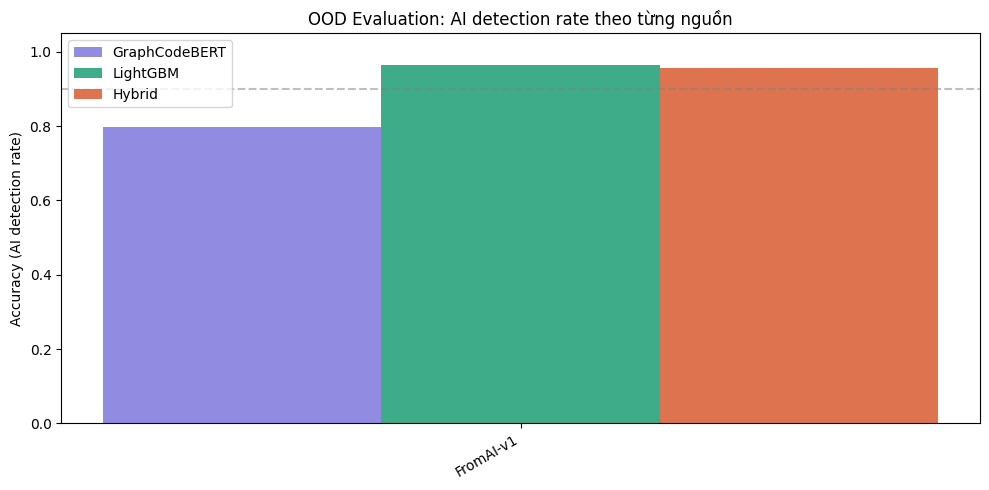

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

x      = np.arange(len(df_results))
width  = 0.25
labels = df_results['Nguồn AI'].tolist()

ax.bar(x - width, df_results['BERT'].astype(float),
       width, label='GraphCodeBERT', color='#7F77DD', alpha=0.85)
ax.bar(x,         df_results['LightGBM'].astype(float),
       width, label='LightGBM',      color='#1D9E75', alpha=0.85)
ax.bar(x + width, df_results['Hybrid'].astype(float),
       width, label='Hybrid',        color='#D85A30', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Accuracy (AI detection rate)')
ax.set_ylim(0, 1.05)
ax.set_title('OOD Evaluation: AI detection rate theo từng nguồn')
ax.legend()
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='threshold 90%')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'ood_ai_accuracy_by_source.png', dpi=150)
plt.show()